In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 06 — Chains, boundaries, homology, and Betti numbers

Read `lessons/06_lesson.md` first. Predict each result before execution. This is a fully worked lab; independent exercises and solutions are separate. All real examples before Stage 12 restrict digit displays to training data.

## Setup
This cell locates the project, loads standard numerical tools, and creates only this stage’s output folder. The mathematical work begins below.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/manifest.json").exists() and (p / "src/shape_lab").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the extracted listening_to_shape_lab folder.")
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.display import show_and_save, save_json
OUT = ROOT / "reports/stage_06"
OUT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT.relative_to(ROOT))

Output folder: reports/stage_06


## Boundary matrices and the triangle
Each column is the boundary of one simplex. Entries are in F₂.

In [3]:
from shape_lab.algebra import closure, boundary_matrix, betti_numbers, euler_characteristic
boundary = closure([(0,1),(0,2),(1,2)])
filled = closure([(0,1,2)])
print("d1 for the filled triangle:", boundary_matrix(filled, 1), sep="\n")
print("d2:", boundary_matrix(filled, 2), sep="\n")
assert not np.any((boundary_matrix(filled, 1) @ boundary_matrix(filled, 2)) % 2)
print("Boundary Betti:", betti_numbers(boundary), "Filled Betti:", betti_numbers(filled))
assert betti_numbers(boundary) == [1,1]
assert betti_numbers(filled) == [1,0,0]

d1 for the filled triangle:
[[1 1 0]
 [1 0 1]
 [0 1 1]]
d2:
[[1]
 [1]
 [1]]
Boundary Betti: [1, 1] Filled Betti: [1, 0, 0]


## Real image through thresholds
Every threshold is a separate subcomplex of the same declared pixel filtration. Betti numbers need not vary monotonically.

 threshold  beta0  beta1  euler
      0.00      3      0      3
      0.25      1      1      0
      0.50      1      2     -1
      0.75      1      2     -1
      1.00      1      0      1

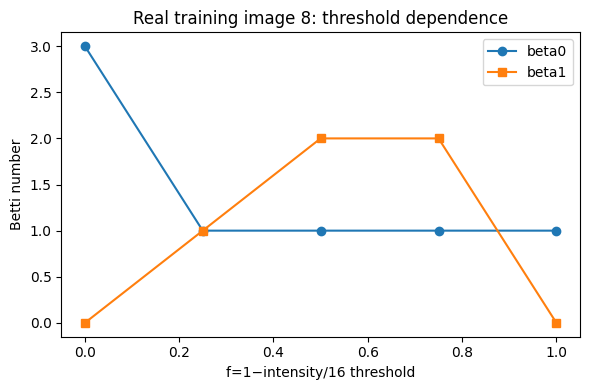

In [4]:
from shape_lab.data import digit_example
from shape_lab.persistence import pixel_filtration
image, sample_id = digit_example(8)
f = pixel_filtration(1-image.astype(float)/16)
rows = []
for t in [0, .25, .5, .75, 1.]:
    complex_ = [s for s, value in f if value<=t]
    b = betti_numbers(complex_, max_dim=1)
    chi = euler_characteristic(complex_)
    assert chi == b[0] - b[1]  # selected subsets of this planar pixel region have no H2
    rows.append({"threshold": t, "beta0": b[0], "beta1": b[1], "euler": chi})
print(pd.DataFrame(rows).to_string(index=False))
assert rows[-1]["beta0"] == 1 and rows[-1]["beta1"] == 0
plt.figure(figsize=(6,4))
plt.plot([r["threshold"] for r in rows], [r["beta0"] for r in rows], marker="o", label="beta0")
plt.plot([r["threshold"] for r in rows], [r["beta1"] for r in rows], marker="s", label="beta1")
plt.legend(); plt.xlabel("f=1−intensity/16 threshold"); plt.ylabel("Betti number")
plt.title(f"Real training image {sample_id}: threshold dependence")
show_and_save(OUT / "digit_betti_thresholds.png")
save_json(OUT / "results.json", {"sample_id": sample_id, "coefficients": "F2", "homology": "ordinary", "threshold_results": rows})

## Mastery gate
Calculate small homology groups by hand, prove boundary-of-boundary, and explain every term in the Betti formula.

A successful Run All is computational evidence, not a learner pass. Complete the lesson’s original exercises before reading `solutions/06_solutions.md`. Record independent work, corrections and a delayed re-test in your learner ledger.

## Sources and conventions
Source IDs: R1, R2, R7; direct links and assignments are in `docs/SOURCES.md`. Core conventions are in `docs/MATHEMATICAL_CONVENTIONS.md`.